<a href="https://colab.research.google.com/github/Heman659-crypto/IDRA-patient-length-of-stay-prediction-ml-model/blob/main/LengthOfStay_Capstone_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Analytics for Healthcare: Forecasting Patient Length of Stay in Urban Hospitals

**A Regression-Based Analysis of Admission-Time Predictors of Inpatient Length of Stay**

| | |
|---|---|
| **Programme** | **IDRA Data Science & AI Training Program — Capstone Project 2026**|
| **Project track** | **ML Model for prediction of patient's length of Stay in urban Hospital**|
| **Author** |**Heman**|
| **Institute name** |**Guru Nanak Dev University**|
|**Training organised by**|**Indian Data Research Academy**|
| **Dataset** |`P_1_LengthOfStay.csv` (61,680 inpatient admission records) |
| **Target variable** | `lengthofstay` (days) |
| **Date** | **20/09/2026** |

---

## Abstract

Hospital length of stay (LOS) is a key driver of bed capacity, staffing and discharge planning, yet
it is rarely known with confidence at the moment a patient is admitted. This project asks whether LOS
can be predicted from information that is genuinely available at admission — demographics, prior
readmission history, comorbidity flags and admission-time clinical measurements — for 61,680 inpatient
records in `P_1_LengthOfStay.csv`. A structured audit found the raw data to be largely clean (no
missing values, no duplicates) and identified one leakage variable (`discharged`, which reproduces the
target exactly) and one invalid clinical value, both handled with minimal, justified corrections.
Exploratory and statistical analysis identified prior readmission count (`rcount`) as by far the
strongest correlate of LOS (r ≈ 0.75), followed by facility identity and a small set of comorbidity
flags. Three regression models were trained inside leakage-safe Scikit-learn pipelines: a mean
baseline, Linear Regression, and a Random Forest Regressor. The Random Forest was the strongest
performer, explaining roughly 87% of test-set variance in LOS (R² ≈ 0.87) at a mean absolute error of
under one day, versus effectively zero explanatory power for the baseline — while Linear Regression
alone still explained over 75% of test-set variance, showing that much of the relationship is close to
linear. Residual analysis showed the model is most reliable for the common 1–8 day range and least
reliable for rare, long-stay outliers. The findings support using admission-time readmission history
and specific comorbidities to flag patients for early discharge-planning attention, while stopping
short of any causal or clinical claim about what drives a longer stay.

**Keywords:** length of stay, healthcare analytics, regression, exploratory data analysis, feature
engineering, target leakage, Random Forest

## Table of Contents

1. [Project Title and Overview](#1-project-title-and-overview)
2. [Research Problem](#2-research-problem)
3. [Objectives](#3-objectives)
4. [Research Questions](#4-research-questions)
5. [Dataset Description](#5-dataset-description)
6. [Data Quality Assessment](#6-data-quality-assessment)
7. [Data Cleaning](#7-data-cleaning)
8. [Target Leakage Investigation](#8-target-leakage-investigation)
9. [Feature Engineering](#9-feature-engineering)
10. [Exploratory Data Analysis](#10-exploratory-data-analysis)
11. [Statistical Analysis](#11-statistical-analysis)
12. [Machine Learning Methodology](#12-machine-learning-methodology)
13. [Model Development](#13-model-development)
14. [Model Evaluation](#14-model-evaluation)
15. [Model Interpretation](#15-model-interpretation)
16. [Results Table](#16-results-table)
17. [Discussion](#17-discussion)
18. [Limitations](#18-limitations)
19. [Recommendations](#19-recommendations)
20. [Conclusion](#20-conclusion)
21. [Reproducibility](#21-reproducibility)

*(Section links work when this notebook is viewed on GitHub or in JupyterLab*

---
# PART I — Problem & Data Understanding
*Sections 1–6: define the problem, state objectives and research questions, load the data, and audit its quality before touching anything.*
---

## 1. Project Title and Overview

### 1.1 About this notebook

This notebook is the full, reproducible analytical record behind the capstone report. It follows a
research-style workflow: understand the problem and the data, audit data quality before touching
anything, clean only what is demonstrably wrong, prevent target leakage, engineer features that are
honestly available at prediction time, explore the data with a small number of purposeful charts,
apply the statistics covered in the programme, build and compare regression models inside
Scikit-learn pipelines, evaluate them honestly (including overfitting/underfitting), interpret the
final model, and close with limitations, recommendations and a conclusion that answers the research
question.

Every number reported below is computed live from `P_1_LengthOfStay.csv` in this notebook — nothing
is hard-coded or invented.

### 1.2 Environment and setup

The cell below loads every library used in this notebook, fixes the random seed, and defines a single
consistent colour palette applied to every chart — so colour always means the same thing throughout
(blue = observed data, green = model output, red = reference line).

In [62]:
# Core libraries used throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility: a single fixed random seed is used everywhere a random_state is accepted
RANDOM_STATE = 42

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# A single, consistent visual identity used across every figure in this notebook, so that colour
# always means the same thing (blue = primary metric, green = model output, red = reference line).
PALETTE = {
    'primary': '#2563eb',    # blue   -- primary distributions / observed data
    'secondary': '#059669',  # green  -- model results / feature importance
    'accent': '#dc2626',     # red    -- reference lines, callouts, key thresholds
    'tertiary': '#d97706',   # amber  -- secondary clinical distributions
    'neutral': '#64748b',    # slate  -- muted annotation text
}
CATEGORICAL_PALETTE = ['#2563eb', '#059669', '#d97706', '#dc2626', '#7c3aed']  # facility-level charts

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#334155', 'axes.labelsize': 11, 'axes.labelweight': 'medium',
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'grid.alpha': 0.35, 'font.size': 10.5, 'legend.frameon': False,
})

print("Libraries loaded. Random seed fixed at", RANDOM_STATE)

Libraries loaded. Random seed fixed at 42


### 1.3 Notebook roadmap

The 21 sections of this notebook are organised into five working phases, matching how a data science
project actually proceeds — understand, prepare, analyse, model, synthesise:

| Phase | Sections | Purpose |
|---|---|---|
| **I. Problem & Data Understanding** | 1–6 | Define the problem, state objectives and research questions, load the data, audit its quality |
| **II. Data Preparation** | 7–9 | Clean only what is demonstrably wrong, remove target leakage, engineer honest features |
| **III. Analysis** | 10–11 | Explore the data visually and statistically to find what actually predicts length of stay |
| **IV. Modelling & Evaluation** | 12–16 | Build, evaluate and interpret regression models inside leakage-safe pipelines |
| **V. Synthesis** | 17–21 | Connect findings into a discussion, limitations, recommendations and conclusion |

The diagram below shows the same pipeline visually.

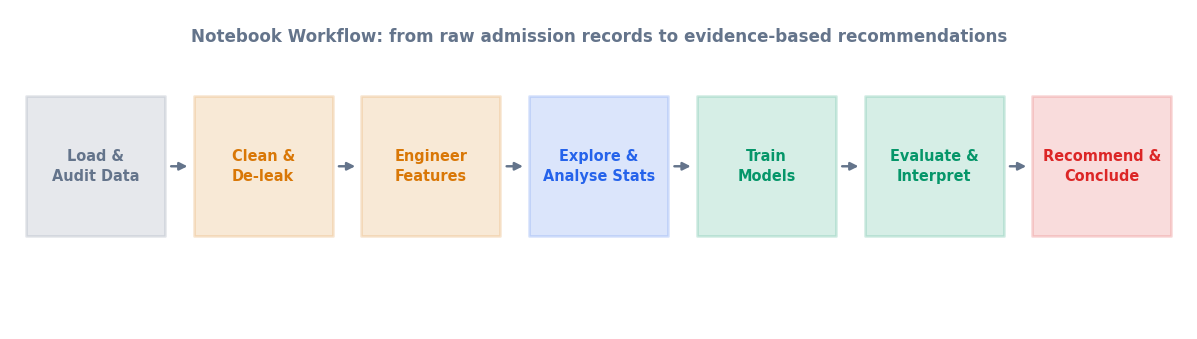

In [63]:
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 11); ax.set_ylim(0, 2.6); ax.axis('off')

stages = ['Load &\nAudit Data', 'Clean &\nDe-leak', 'Engineer\nFeatures', 'Explore &\nAnalyse Stats',
          'Train\nModels', 'Evaluate &\nInterpret', 'Recommend &\nConclude']
stage_colors = [PALETTE['neutral'], PALETTE['tertiary'], PALETTE['tertiary'], PALETTE['primary'],
                PALETTE['secondary'], PALETTE['secondary'], PALETTE['accent']]
n = len(stages)
box_w, box_h, gap = 1.3, 1.15, 0.27
total_w = n * box_w + (n - 1) * gap
x0 = (11 - total_w) / 2
y0 = 0.75

for i, (label, color) in enumerate(zip(stages, stage_colors)):
    x = x0 + i * (box_w + gap)
    ax.add_patch(plt.Rectangle((x, y0), box_w, box_h, facecolor=color, alpha=0.16,
                                edgecolor=color, linewidth=1.8, joinstyle='round'))
    ax.text(x + box_w / 2, y0 + box_h / 2, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=color, linespacing=1.4)
    if i < n - 1:
        ax.annotate('', xy=(x + box_w + gap - 0.03, y0 + box_h / 2), xytext=(x + box_w + 0.03, y0 + box_h / 2),
                     arrowprops=dict(arrowstyle='-|>', color=PALETTE['neutral'], linewidth=1.6))

ax.text(11 / 2, y0 + box_h + 0.45, 'Notebook Workflow: from raw admission records to evidence-based recommendations',
        ha='center', fontsize=11, fontweight='bold', color=PALETTE['neutral'])
plt.tight_layout()
plt.show()

## 2. Research Problem

Urban hospitals operate under constant pressure on bed capacity, staffing and discharge planning.
A patient's **length of stay (LOS)** — the number of days between admission and discharge — is one
of the most operationally important outcomes a hospital can try to anticipate: it drives bed
availability, staffing rosters, discharge planning and cost.

If a patient's length of stay could be estimated reasonably well **at the time of admission**, using
only information that is already available then (demographics, admission-time vitals, pre-existing
conditions, and prior readmission history), hospital operations and care-coordination teams could
plan resources proactively rather than reactively.

This project investigates whether such admission-time information can be used to build a regression
model that predicts a patient's length of stay in an urban hospital setting, using the
`P_1_LengthOfStay.csv` dataset of inpatient admission records.

## 3. Objectives

1. Assess the quality of the `P_1_LengthOfStay` dataset and resolve only the issues that are
   demonstrably present, with each decision justified.
2. Identify and remove variables that would leak the target (information only knowable after
   discharge) before any modelling is attempted.
3. Engineer admission-time features from the admission date that are legitimately available at the
   moment a prediction would be made.
4. Explore the data to identify which patient, clinical and hospital-operational variables are most
   associated with length of stay.
5. Build and compare a baseline and two regression models (Linear Regression and Random Forest) to
   predict `lengthofstay`, and evaluate them using MAE, RMSE and R².
6. Interpret the best-performing model's errors and important features, and translate the findings
   into evidence-based, actionable recommendations for hospital operations.

## 4. Research Questions

**Primary research question:** Can a patient's length of stay be predicted with useful accuracy
at admission time, using demographic, clinical and hospital-operational variables?

Supporting questions:

- What is the quality of the dataset (missing values, duplicates, invalid or inconsistent values,
  outliers), and what treatment, if any, is genuinely required?
- Does the discharge date trivially reveal the target, and if so, how should that be handled?
- Which admission-time variables (comorbidities, prior readmissions, vitals, facility) show the
  strongest association with length of stay?
- How much does length of stay vary across facilities, genders and readmission history?
- How much better than a naive baseline can a trained regression model perform, and does the chosen
  model generalise from training to unseen data or does it overfit?
- Which features matter most to the final model's predictions, and what are the practical limits of
  interpreting that importance?

## 5. Dataset Description

### 5.1 Source

The dataset was supplied for this capstone as `P_1_LengthOfStay.csv`. The files provided with the
assignment do not include a data-collection statement, institution name or license, so the original
collecting institution cannot be confirmed and is **not** asserted here. What can be established
directly from the file's structure: it contains one row per inpatient admission, with an admission
date (`vdate`), a discharge date (`discharged`), a facility code (`facid`), and a set of admission-time
clinical and comorbidity fields, consistent with a hospital inpatient-operations extract. Where a
variable's exact clinical meaning is not documented (see `secondarydiagnosisnonicd9` below), that
uncertainty is stated explicitly rather than guessed at.

### 5.2 Loading the data

In [64]:
from pathlib import Path
import pandas as pd
from google.colab import files

# ---------------------------------------------------------
# 1. Upload dataset
# ---------------------------------------------------------
print("Please upload: P_1_LengthOfStay.csv")

uploaded = files.upload()

if not uploaded:
    raise FileNotFoundError("No file was uploaded.")

# Get the uploaded filename
uploaded_filename = next(iter(uploaded))
DATA_PATH = Path(uploaded_filename)

print(f"\nDataset selected: {DATA_PATH.name}")

# ---------------------------------------------------------
# 2. Validate filename
# ---------------------------------------------------------
expected_filename = "P_1_LengthOfStay.csv"

if DATA_PATH.name != expected_filename:
    print(
        f"Warning: Expected '{expected_filename}', "
        f"but received '{DATA_PATH.name}'."
    )

# ---------------------------------------------------------
# 3. Load dataset
# ---------------------------------------------------------
df_raw = pd.read_csv(DATA_PATH)

# ---------------------------------------------------------
# 4. Validate required columns
# ---------------------------------------------------------
required_columns = {
    "eid",
    "lengthofstay",
    "vdate",
    "discharged",
    "rcount",
    "gender",
    "facid",
}

missing_required = required_columns.difference(df_raw.columns)

if missing_required:
    raise ValueError(
        f"Required columns are missing: {sorted(missing_required)}"
    )

# ---------------------------------------------------------
# 5. Basic dataset information
# ---------------------------------------------------------
print("\nDataset loaded successfully.")
print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")

display(df_raw.head())

Please upload: P_1_LengthOfStay.csv


Saving P_1_LengthOfStay (1).csv to P_1_LengthOfStay (1) (1).csv

Dataset selected: P_1_LengthOfStay (1) (1).csv

Dataset loaded successfully.
Rows: 61,680
Columns: 28


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


### 5.3 Data dictionary (key variables)

| Variable | Meaning | Type | Role |
|---|---|---|---|
| `eid` | Row/encounter identifier | Integer | Identifier (excluded — see Section 8) |
| `vdate` | Admission (visit) date | Date (text) | Used only to engineer admission-time features (Section 9) |
| `discharged` | Discharge date | Date (text) | Excluded — reveals the target (Section 8) |
| `rcount` | Number of prior readmissions in the last 180 days (`'5+'` = 5 or more, top-coded) | Categorical/ordinal | Feature |
| `gender` | Patient gender (`F`/`M`) | Categorical | Feature |
| `facid` | Treating facility code (`A`–`E`) | Categorical | Feature |
| `dialysisrenalendstage`, `asthma`, `irondef`, `pneum`, `substancedependence`, `psychologicaldisordermajor`, `depress`, `psychother`, `fibrosisandother`, `malnutrition`, `hemo` | Presence (1) / absence (0) of each condition at admission | Binary (0/1) | Features (11 comorbidity/condition flags) |
| `hematocrit`, `neutrophils`, `sodium`, `glucose`, `bloodureanitro`, `creatinine`, `bmi`, `pulse`, `respiration` | Admission-time laboratory / vital measurements | Continuous numeric | Features |
| `secondarydiagnosisnonicd9` | Count of secondary diagnoses not coded under the primary ICD-9 classification — inferred from the column name; **not confirmed by any supplied data dictionary** | Integer | Feature (used cautiously) |
| `lengthofstay` | Number of days between admission and discharge | Integer | **Target** |

### 5.4 Target and predictors

- **Target (`y`):** `lengthofstay` — a continuous count of days, which is why this is framed as a
  **regression** problem.
- **Predictors (`X`):** all admission-time demographic, comorbidity, clinical and facility variables,
  plus admission-date-derived features engineered in Section 9. `eid`, `vdate` and `discharged` are
  excluded from the modelling feature set for the reasons documented in Sections 8–9.

### 5.5 Dataset limitations (stated upfront, revisited in Section 18)

- No documented source institution, geography beyond facility codes, or data-collection period beyond
  what can be derived from the dates themselves.
- No socio-economic, insurance, race/ethnicity or admission-type (emergency vs elective) variables —
  factors commonly relevant to length of stay in the wider literature are simply not present here.
- The meaning of `secondarydiagnosisnonicd9` is inferred, not documented.
- As shown in Section 6, several extreme clinical values appear as **exact duplicate pairs** across
  different patients, which is unusual for organically collected clinical data and suggests the
  dataset may be partially simulated — this is treated as a representativeness caveat, not corrected.

## 6. Data Quality Assessment

Every check below follows the same discipline: detect → quantify → decide whether it is actually a
problem → (in Section 7) treat only what needs treating → validate.

In [65]:
print("Dataset dimensions:", df_raw.shape)
print("\nColumn names:")
print(list(df_raw.columns))

Dataset dimensions: (61680, 28)

Column names:
['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay']


In [66]:
print("Data types:")
df_raw.dtypes.to_frame('dtype')

Data types:


,dtype
eid,int64
vdate,object
rcount,object
gender,object
dialysisrenalendstage,int64
asthma,int64
irondef,int64
pneum,int64
substancedependence,int64
psychologicaldisordermajor,int64


In [67]:
missing_counts = df_raw.isnull().sum()
missing_pct = (missing_counts / len(df_raw) * 100).round(3)
missing_report = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0] if missing_report['missing_count'].sum() > 0 else \
    print("No missing values were found in any of the", df_raw.shape[1], "columns. No imputation is required.")

No missing values were found in any of the 28 columns. No imputation is required.


**Observation:** zero missing values across all 28 columns. **Decision:** no imputation of any kind
is required — this is reported explicitly rather than silently skipped, as instructed.

In [68]:
dup_count = df_raw.duplicated().sum()
print(f"Fully duplicated rows: {dup_count}")
if dup_count == 0:
    print("No duplicate records were found. No de-duplication is required.")

Fully duplicated rows: 0
No duplicate records were found. No de-duplication is required.


In [69]:
# eid: is it a true unique identifier, or a meaningful predictor?
print("Unique eid values:", df_raw['eid'].nunique(), "out of", len(df_raw), "rows")

print("\nUnique categories — rcount:", sorted(df_raw['rcount'].unique()))
print("Unique categories — gender:", sorted(df_raw['gender'].unique()))
print("Unique categories — facid:", sorted(df_raw['facid'].unique()))
print("\nrcount value counts:")
print(df_raw['rcount'].value_counts().sort_index())

Unique eid values: 61680 out of 61680 rows

Unique categories — rcount: ['0', '1', '2', '3', '4', '5+']
Unique categories — gender: ['F', 'M']
Unique categories — facid: ['A', 'B', 'C', 'D', 'E']

rcount value counts:
rcount
0     33976
1      9268
2      6152
3      4961
4      4273
5+     3050
Name: count, dtype: int64


**Observations:** `eid` is unique for every one of the 61,680 rows — it is a row identifier, not a
predictive variable, and will be excluded from modelling (Section 8). `gender` and `facid` contain
only clean, expected categories. `rcount` is stored as **text**, and its top category `'5+'` is a
**top-coded / censored** value (5 or more prior readmissions collapsed into one label) rather than an
exact count — this is a data-type and representation issue to fix in Section 7, not a missing-value
or outlier issue.

In [70]:
# Date validity: do vdate / discharged parse cleanly, and is discharge always on/after admission?
vdate_parsed = pd.to_datetime(df_raw['vdate'], errors='coerce')
discharged_parsed = pd.to_datetime(df_raw['discharged'], errors='coerce')

print("Unparseable vdate values:", vdate_parsed.isna().sum())
print("Unparseable discharged values:", discharged_parsed.isna().sum())
print("vdate range:", vdate_parsed.min().date(), "to", vdate_parsed.max().date())
print("discharged range:", discharged_parsed.min().date(), "to", discharged_parsed.max().date())

stay_days = (discharged_parsed - vdate_parsed).dt.days
print("\nRows where discharged is earlier than vdate (invalid):", (stay_days < 0).sum())
print("Implied stay length (discharged - vdate) summary:")
stay_days.describe()

Unparseable vdate values: 0
Unparseable discharged values: 0
vdate range: 2012-01-01 to 2013-01-01
discharged range: 2012-01-02 to 2013-01-13

Rows where discharged is earlier than vdate (invalid): 0
Implied stay length (discharged - vdate) summary:


,0
count,61680.000000
mean,3.999368
std,2.357744
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,17.000000


**Observations:** both date columns parse without error for all 61,680 rows, and discharge is never
before admission. The implied stay length computed from the two dates has exactly the same
distribution as `lengthofstay` (min 1, max 17, mean ≈ 4) — this is the first hint investigated formally
in Section 8 (Target Leakage Investigation).

In [103]:
# Numerical ranges for continuous clinical variables
numeric_check_cols = ['hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
                       'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9']
df_raw[numeric_check_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
hematocrit,61680.0,11.966872,2.038621,4.400000,10.900000,11.900000,12.900000,24.100000
neutrophils,61680.0,10.196406,5.271263,0.100000,7.700000,9.400000,11.500000,245.900000
sodium,61680.0,137.896793,3.000727,124.912632,135.874040,137.900871,139.914345,151.387283
glucose,61680.0,142.052746,29.923142,-1.005927,121.873358,142.249278,162.207568,268.571156
bloodureanitro,61680.0,14.113017,12.749797,1.000000,11.000000,12.000000,14.000000,682.500000
creatinine,61680.0,1.099037,0.200437,0.219770,0.964564,1.098405,1.235104,2.035202
bmi,61680.0,29.803679,2.000390,22.037695,28.456682,29.804745,31.152721,38.935293
pulse,61680.0,73.422568,11.651837,21.000000,66.000000,73.000000,81.000000,126.000000
respiration,61680.0,6.492793,0.572551,0.200000,6.500000,6.500000,6.500000,10.000000
secondarydiagnosisnonicd9,61680.0,2.122455,2.053596,0.000000,1.000000,1.000000,3.000000,10.000000


**Observation:** `glucose` has a minimum of about **-1.01**, which is physiologically impossible
(blood glucose cannot be negative) — flagged for treatment in Section 7. All other ranges are
plausible for hospital laboratory measurements, though several (`bloodureanitro`, `neutrophils`) have
maxima far above their median, which is investigated next as a skew/outlier question rather than an
invalid-value question.

In [104]:
def iqr_outlier_scan(frame, cols):
    """Flag values outside 1.5x IQR for each column; report count and percentage only (no removal)."""
    rows = []
    for c in cols:
        q1, q3 = frame[c].quantile(0.25), frame[c].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flagged = (frame[c] < lo) | (frame[c] > hi)
        rows.append({'variable': c, 'lower_fence': round(lo, 2), 'upper_fence': round(hi, 2),
                     'min': round(frame[c].min(), 2), 'max': round(frame[c].max(), 2),
                     'n_flagged': int(flagged.sum()), 'pct_flagged': round(flagged.mean() * 100, 2)})
    return pd.DataFrame(rows)

outlier_scan = iqr_outlier_scan(df_raw, numeric_check_cols + ['pulse'])
outlier_scan = outlier_scan.drop_duplicates(subset='variable').reset_index(drop=True)
outlier_scan

,variable,lower_fence,upper_fence,min,max,n_flagged,pct_flagged
0,hematocrit,7.90,15.90,4.40,24.10,3497,5.67
1,neutrophils,2.00,17.20,0.10,245.90,4071,6.60
2,sodium,129.81,145.97,124.91,151.39,464,0.75
3,glucose,61.37,222.71,-1.01,268.57,441,0.71
4,bloodureanitro,6.50,18.50,1.00,682.50,12043,19.52
5,creatinine,0.56,1.64,0.22,2.04,411,0.67
6,bmi,24.41,35.20,22.04,38.94,420,0.68
7,pulse,43.50,103.50,21.00,126.00,658,1.07
8,respiration,6.50,6.50,0.20,10.00,21856,35.43
9,secondarydiagnosisnonicd9,-2.00,6.00,0.00,10.00,3126,5.07


In [73]:
# Two flagged variables need a closer look before any decision is made: respiration (very high flag rate)
# and bloodureanitro / neutrophils (extreme maxima).
print("respiration — value counts (top 8):")
print(df_raw['respiration'].value_counts().head(8))
print(f"\n'respiration' == 6.5 for {(df_raw['respiration'] == 6.5).mean()*100:.1f}% of patients")

print("\nbloodureanitro > 100 in", (df_raw['bloodureanitro'] > 100).sum(), "rows")
print("Correlation between dialysisrenalendstage flag and bloodureanitro:",
      round(df_raw['dialysisrenalendstage'].corr(df_raw['bloodureanitro']), 3))

print("\nglucose < 0 in", (df_raw['glucose'] < 0).sum(), "row(s) — value(s):",
      df_raw.loc[df_raw['glucose'] < 0, 'glucose'].tolist())

respiration — value counts (top 8):
respiration
6.5    39824
6.9      953
6.4      923
6.2      904
6.6      890
6.3      880
6.1      870
6.7      861
Name: count, dtype: int64

'respiration' == 6.5 for 64.6% of patients

bloodureanitro > 100 in 110 rows
Correlation between dialysisrenalendstage flag and bloodureanitro: 0.269

glucose < 0 in 1 row(s) — value(s): [-1.005926859]


**Interpretation — do not blindly trust the mechanical IQR flag:**

- **`respiration`** is flagged as having outliers in roughly a third of rows, but this is because
  **64–65% of patients share the exact same value (6.5)**, which collapses the IQR fence almost onto
  the median itself — any small deviation from 6.5 then gets mechanically flagged. This is a
  **clustered/near-constant distribution**, not a population of erroneous measurements. No treatment
  is applied; the IQR method is simply not appropriate for a variable this concentrated.
- **`bloodureanitro`** and **`neutrophils`** are right-skewed with a small number of very high values
  (up to 682.5 and 245.9 respectively). These are clinically plausible in severe renal or infectious
  presentations — `bloodureanitro` correlates positively (r ≈ 0.27) with the `dialysisrenalendstage`
  comorbidity flag, supporting a clinical rather than erroneous origin. They are **retained**; their
  skew is instead handled analytically by preferring the **median** over the mean when summarising
  them (Section 11), and by not scaling them into a model that assumes normality (Section 12).
- **`glucose`** has exactly **one** physiologically invalid negative value out of 61,680 rows. This is
  a genuine data-entry error (a real measurement cannot be negative) and is corrected in Section 7 —
  the single affected row is not dropped, since 27 other variables on that row remain informative;
  only the invalid cell is treated.

### Summary of Data-Quality Findings

| Check | Finding | Decision |
|---|---|---|
| Missing values | 0 across all 28 columns | No imputation needed |
| Duplicate rows | 0 | No de-duplication needed |
| `eid` | 100% unique | Excluded as a row identifier |
| `rcount` | Stored as text; `'5+'` is top-coded | Convert to ordinal integer, cap at 5 (Section 7) |
| `vdate` / `discharged` | Parse cleanly; discharge never precedes admission | `discharged` excluded — leaks target (Section 8) |
| `glucose` | 1 physiologically invalid negative value | Treat as invalid → impute that cell with the column median (Section 7) |
| `respiration` | ~64% clustered at 6.5; IQR flags ~35% mechanically | Retained as-is; IQR not appropriate for this distribution |
| `bloodureanitro`, `neutrophils` | Right-skewed, clinically plausible extreme values | Retained; summarised with median, not scaled blindly |
| Other numeric vars (`hematocrit`, `sodium`, `creatinine`, `bmi`, `pulse`) | <2% IQR-flagged, plausible ranges | Retained, no treatment |

---
# PART II — Data Preparation
*Sections 7–9: cleaned  only what is demonstrably wrong, remove target leakage, and engineer features that are honestly available at prediction time.*
---

## 7. Data Cleaning

Only two changes are justified by the audit above: converting `rcount` to a numeric ordinal scale, and
correcting the single invalid `glucose` value. Nothing else is altered.

In [74]:
df_clean = df_raw.copy()

# (1) rcount: text -> ordinal integer. '5+' is a top-coded ceiling, mapped to 5.
before_dtype = df_clean['rcount'].dtype
df_clean['rcount'] = df_clean['rcount'].replace('5+', '5').astype(int)
print(f"rcount dtype: {before_dtype} -> {df_clean['rcount'].dtype}")
print("rcount range after conversion:", df_clean['rcount'].min(), "to", df_clean['rcount'].max())

rcount dtype: object -> int64
rcount range after conversion: 0 to 5


In [75]:
# (2) glucose: exactly one physiologically invalid negative value -> treat as invalid, impute with median
n_invalid_glucose = (df_clean['glucose'] < 0).sum()
glucose_median = df_clean.loc[df_clean['glucose'] >= 0, 'glucose'].median()

df_clean.loc[df_clean['glucose'] < 0, 'glucose'] = np.nan
df_clean['glucose'] = df_clean['glucose'].fillna(glucose_median)

print(f"Invalid glucose values corrected: {n_invalid_glucose}")
print(f"Replacement value used (median of valid glucose readings): {glucose_median:.2f}")
print("Remaining negative glucose values after correction:", (df_clean['glucose'] < 0).sum())

Invalid glucose values corrected: 1
Replacement value used (median of valid glucose readings): 142.25
Remaining negative glucose values after correction: 0


In [76]:
# Validation: re-run the core quality checks on the cleaned frame
print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Duplicate rows remaining:", df_clean.duplicated().sum())
print("rcount dtype:", df_clean['rcount'].dtype, " | unique values:", sorted(df_clean['rcount'].unique()))
print("glucose min after cleaning:", round(df_clean['glucose'].min(), 3))
print("\nCleaning validated — dataset is ready for leakage review and feature engineering.")

Missing values remaining: 0
Duplicate rows remaining: 0
rcount dtype: int64  | unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
glucose min after cleaning: 11.048

Cleaning validated — dataset is ready for leakage review and feature engineering.


## 8. Target Leakage Investigation

`vdate` (admission) and `discharged` (discharge) bracket every hospital stay, and `lengthofstay` is,
by definition, the number of days between them. If `discharged` (or a value derived from it) were
left in the feature set, the model would not be *predicting* length of stay — it would be arithmetic.
This is checked directly rather than assumed.

In [77]:
df_clean['vdate_p'] = pd.to_datetime(df_clean['vdate'])
df_clean['discharged_p'] = pd.to_datetime(df_clean['discharged'])

implied_los = (df_clean['discharged_p'] - df_clean['vdate_p']).dt.days
exact_match_pct = (implied_los == df_clean['lengthofstay']).mean() * 100

print(f"Rows where (discharged - vdate) exactly equals lengthofstay: {exact_match_pct:.2f}%")

Rows where (discharged - vdate) exactly equals lengthofstay: 100.00%


**Finding:** `discharged - vdate` equals `lengthofstay` **exactly, for every single row (100%)**.
`discharged` does not merely *correlate* with the target — it **is** the target, expressed as a date
instead of a day count, and it is information that, in a real deployment, would only be known **after**
the patient has already left the hospital.

**Decision:** `discharged` is excluded from the feature set entirely. This is textbook **target
leakage prevention**: including it would let the model achieve a trivially perfect score that could
never be reproduced on a genuinely new, still-admitted patient. `vdate` is retained only long enough
to derive admission-time features in Section 9, and is then dropped as well, since the raw calendar
date itself is not a usable predictor (it does not generalise to future years) and offers no
information beyond what its derived components provide.

`eid` was already established in Section 6 as a 100%-unique row identifier with no predictive meaning,
so it is excluded as well.

## 9. Feature Engineering

From `vdate` (the admission date — always known at prediction time), four candidate features are
derived: admission year, month, day of month, and day of week. Each is tested for a relationship with
`lengthofstay` before being kept, rather than included by default.

In [78]:
df_clean['admission_year'] = df_clean['vdate_p'].dt.year
df_clean['admission_month'] = df_clean['vdate_p'].dt.month
df_clean['admission_day'] = df_clean['vdate_p'].dt.day
df_clean['admission_dayofweek'] = df_clean['vdate_p'].dt.dayofweek  # 0 = Monday

print("admission_year distribution:")
print(df_clean['admission_year'].value_counts())

admission_year distribution:
admission_year
2012    61520
2013      160
Name: count, dtype: int64


In [79]:
print("Mean lengthofstay by admission_month:")
print(df_clean.groupby('admission_month')['lengthofstay'].mean().round(3))
print("\nMean lengthofstay by admission_dayofweek (0=Mon..6=Sun):")
print(df_clean.groupby('admission_dayofweek')['lengthofstay'].mean().round(3))

Mean lengthofstay by admission_month:
admission_month
1     4.030
2     3.952
3     4.028
4     3.981
5     4.024
6     4.003
7     4.002
8     4.008
9     4.032
10    3.968
11    3.962
12    4.000
Name: lengthofstay, dtype: float64

Mean lengthofstay by admission_dayofweek (0=Mon..6=Sun):
admission_dayofweek
0    3.993
1    3.975
2    3.992
3    4.034
4    3.983
5    4.004
6    4.014
Name: lengthofstay, dtype: float64


**Decisions, justified by what was just observed:**

- **`admission_year`** is excluded. 61,520 of 61,680 admissions (99.7%) fall in a single year (2012);
  the remaining 160 rows are simply the first day of the following year. A feature this close to
  constant carries no usable signal and risks the model reading noise into the rare off-year rows.
- **`admission_month`** and **`admission_dayofweek`** are engineered and **retained**. Their group
  means above are essentially flat (all within a few hundredths of a day of the overall mean of ≈4.0),
  so on this one-year sample they carry little standalone signal — this is reported honestly rather
  than dressed up as a finding. They are kept anyway because they are genuinely available at
  prediction time, carry zero leakage risk, add negligible dimensionality, and a larger/multi-year
  sample could plausibly reveal seasonal or weekday effects that this dataset is simply too narrow in
  time to show.
- **`admission_day`** (day of month) is excluded — there is no clinical or operational reason to
  expect the day-of-month number itself to matter, and it is a higher-cardinality feature than month
  or weekday for no added value.

`vdate`, `discharged`, `vdate_p` and `discharged_p` are dropped now that their information has either
been engineered into usable features or ruled out as leakage.

In [105]:
df_model = df_clean.drop(columns=['vdate', 'discharged', 'vdate_p', 'discharged_p',
                                   'admission_day', 'admission_year'])
print("Modelling frame shape:", df_model.shape)
df_model.head(3)

Modelling frame shape: (61680, 28)


,eid,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,facid,lengthofstay,admission_month,admission_dayofweek
0,1,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.2,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,B,3,8,2
1,2,5,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.1,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,A,7,5,5
2,3,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.9,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,B,3,9,5


---
# PART III — Analysis
*Sections 10–11: explore the data visually and statistically to find what actually predicts length of stay.*
---

## 10. Exploratory Data Analysis

The EDA below follows the required sequence — overview, target distribution, numerical
distributions, categorical analysis, group comparisons, numerical relationships, correlation — and
only includes charts that answer one of the research questions from Section 4.

### 10.1 Dataset overview

In [106]:
print("Modelling-ready dataset:", df_model.shape[0], "rows,", df_model.shape[1], "columns")
df_model.describe().T

Modelling-ready dataset: 61680 rows, 28 columns


,count,mean,std,min,25%,50%,75%,max
eid,61680.0,30840.500000,17805.626639,1.000000,15420.750000,30840.500000,46260.250000,61680.000000
rcount,61680.0,1.115386,1.540684,0.000000,0.000000,0.000000,2.000000,5.000000
dialysisrenalendstage,61680.0,0.036365,0.187198,0.000000,0.000000,0.000000,0.000000,1.000000
asthma,61680.0,0.034679,0.182967,0.000000,0.000000,0.000000,0.000000,1.000000
irondef,61680.0,0.095542,0.293964,0.000000,0.000000,0.000000,0.000000,1.000000
pneum,61680.0,0.039559,0.194922,0.000000,0.000000,0.000000,0.000000,1.000000
substancedependence,61680.0,0.062954,0.242882,0.000000,0.000000,0.000000,0.000000,1.000000
psychologicaldisordermajor,61680.0,0.236106,0.424691,0.000000,0.000000,0.000000,0.000000,1.000000
depress,61680.0,0.052205,0.222442,0.000000,0.000000,0.000000,0.000000,1.000000
psychother,61680.0,0.049935,0.217813,0.000000,0.000000,0.000000,0.000000,1.000000


### 10.2 Target distribution: length of stay

*Research question addressed: what does a "typical" hospital stay look like, and how much does it
vary?*

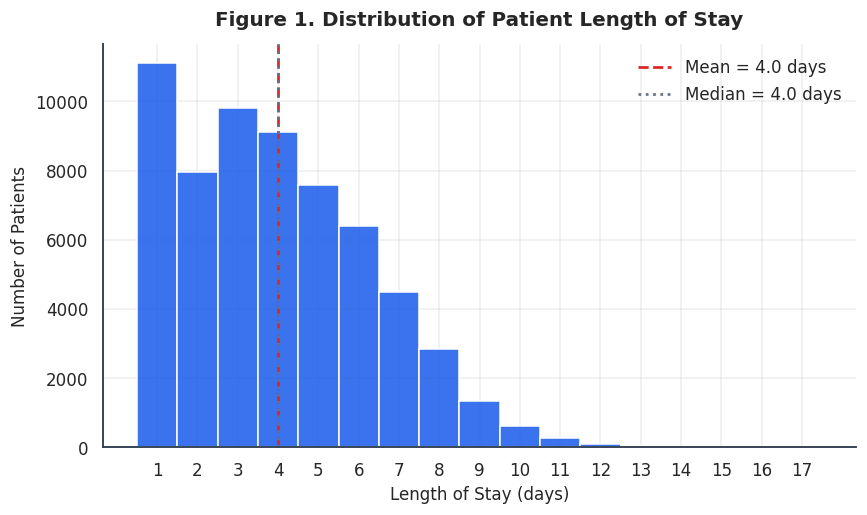

In [107]:
mean_los, median_los = df_model['lengthofstay'].mean(), df_model['lengthofstay'].median()

plt.figure(figsize=(8, 4.8))
ax = sns.histplot(df_model['lengthofstay'], bins=range(1, 19), discrete=True,
                   color=PALETTE['primary'], edgecolor='white', alpha=0.9)
ax.axvline(mean_los, color=PALETTE['accent'], linestyle='--', linewidth=1.8,
           label=f'Mean = {mean_los:.1f} days')
ax.axvline(median_los, color=PALETTE['neutral'], linestyle=':', linewidth=1.8,
           label=f'Median = {median_los:.1f} days')
ax.set_title('Figure 1. Distribution of Patient Length of Stay')
ax.set_xlabel('Length of Stay (days)')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(1, 18))
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**What we observe:** length of stay is right-skewed with a mode at 1 day; the bulk of admissions
resolve within roughly 1–6 days, with a long but thin tail out to 17 days.
**Why it matters:** a small number of long-stay patients disproportionately affect total bed-days, so
a regression model needs to be evaluated not just on typical cases but on how well it handles that
tail (revisited in Section 15).
**Decision it supports:** RMSE (which penalises large errors more than MAE) is included alongside MAE
in Section 14 specifically because of this tail.

### 10.3 Important numerical distribution: Blood Urea Nitrogen

*Research question addressed: how much does BUN — the strongest single clinical measurement
identified later in Section 10.6 — vary across patients?*

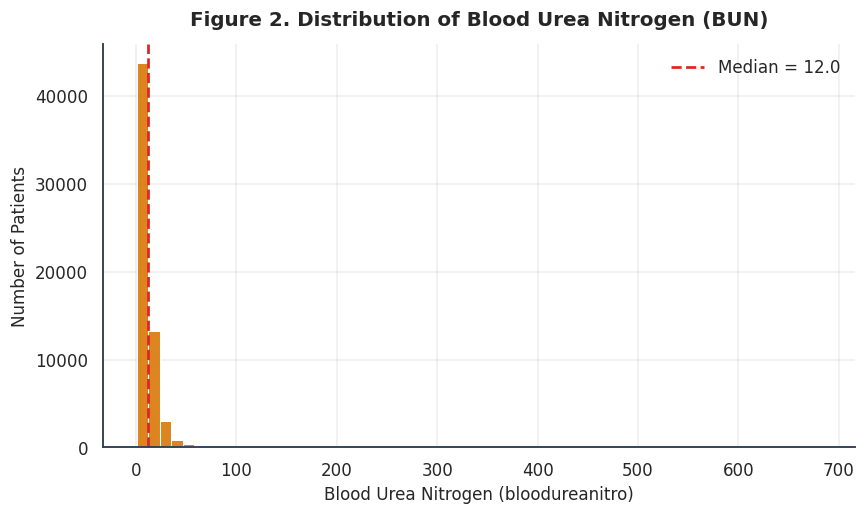

In [108]:
bun_median = df_model['bloodureanitro'].median()

plt.figure(figsize=(8, 4.8))
ax = sns.histplot(df_model['bloodureanitro'], bins=60, color=PALETTE['tertiary'], edgecolor='white', alpha=0.9)
ax.axvline(bun_median, color=PALETTE['accent'], linestyle='--', linewidth=1.8,
           label=f'Median = {bun_median:.1f}')
ax.set_title('Figure 2. Distribution of Blood Urea Nitrogen (BUN)')
ax.set_xlabel('Blood Urea Nitrogen (bloodureanitro)')
ax.set_ylabel('Number of Patients')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**What we observe:** BUN is heavily right-skewed — most patients cluster between roughly 5 and 20,
with a long thin tail of clinically severe values extending past 200 (identified and clinically
contextualised in Section 6).
**Why it matters:** this confirms the Section 6 decision to describe BUN using the **median**, not
the mean, and to avoid feeding it into a model that assumes an approximately normal input distribution
without first checking (Section 12).
**Decision it supports:** BUN is retained un-transformed and is only scaled for the model (Linear
Regression) that actually needs scaling.

### 10.4 Important categorical analysis: comorbidity prevalence

*Research question addressed: which admission-time conditions are common enough in this population
for a model to learn a reliable pattern from?*

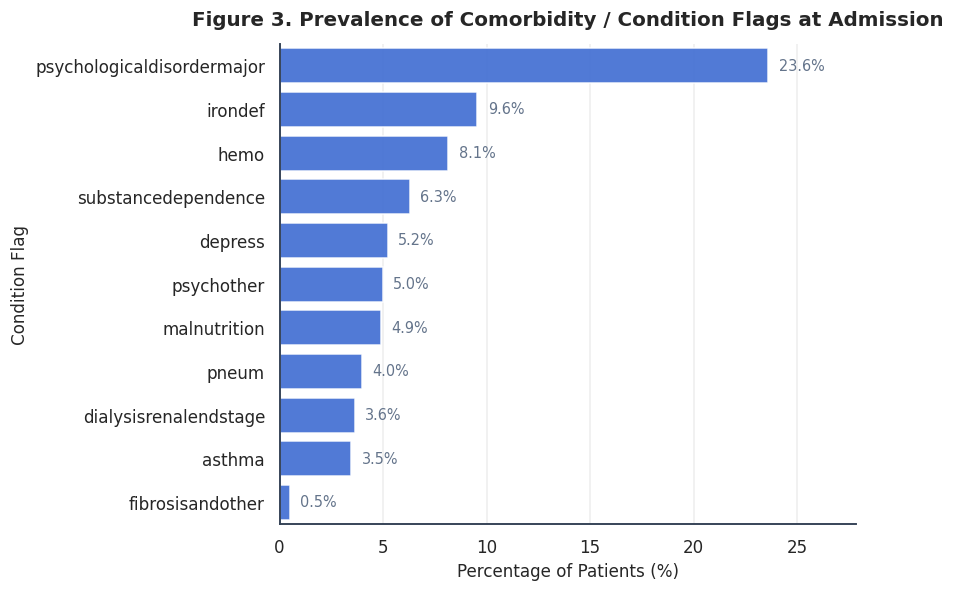

In [109]:
comorbidity_flags = ['dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence',
                      'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother',
                      'malnutrition', 'hemo']
prevalence = (df_model[comorbidity_flags].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 5.5))
ax = sns.barplot(x=prevalence.values, y=prevalence.index, color=PALETTE['primary'], alpha=0.9)
for i, v in enumerate(prevalence.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9.5, color=PALETTE['neutral'])
ax.set_title('Figure 3. Prevalence of Comorbidity / Condition Flags at Admission')
ax.set_xlabel('Percentage of Patients (%)')
ax.set_ylabel('Condition Flag')
ax.set_xlim(0, prevalence.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

**What we observe:** prevalence varies widely across the 11 comorbidity flags, from single digits up
to roughly a third of patients for the most common conditions.
**Why it matters:** several of these flags (notably `psychologicaldisordermajor` and `hemo`) turn out
in Section 11's correlation analysis to be among the strongest non-`rcount` predictors of length of
stay, so it matters that they are common enough in the data to be learnable rather than rare edge
cases.
**Decision it supports:** all 11 flags are kept as binary predictors — none are so rare that they risk
being noise (Section 12).

### 10.5 Group comparisons: length of stay by prior readmission count and by facility

*Research question addressed: how much does length of stay vary across facilities and readmission
history?*

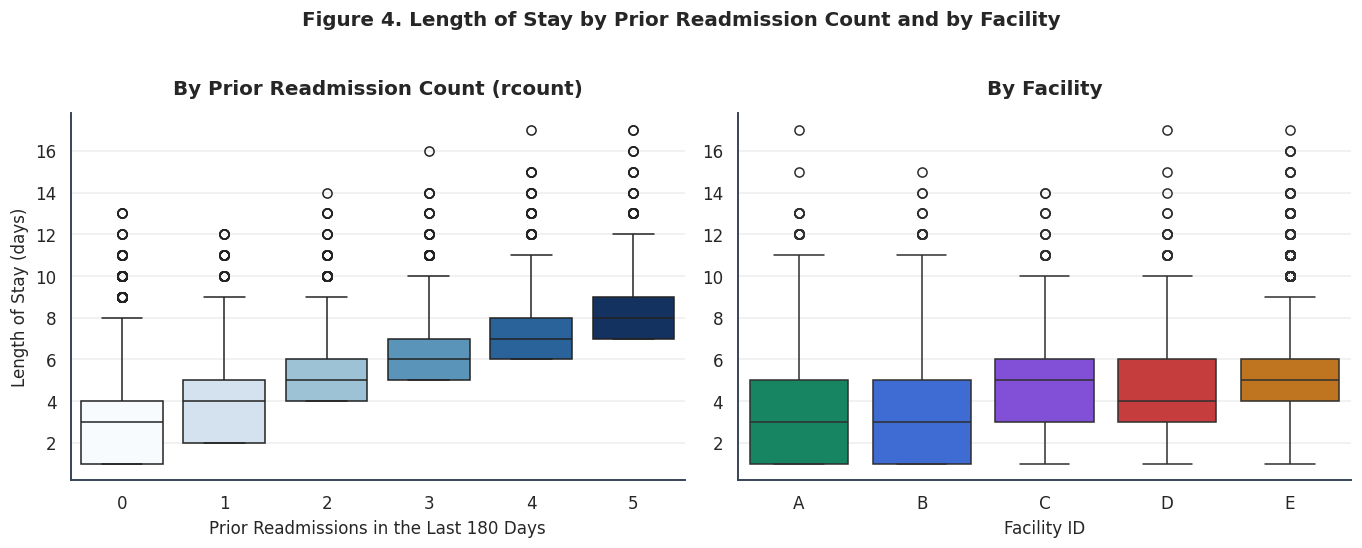

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

rcount_order = sorted(df_model['rcount'].unique())
sns.boxplot(x='rcount', y='lengthofstay', hue='rcount', data=df_model, order=rcount_order,
            palette='Blues', legend=False, ax=axes[0])
axes[0].set_title('By Prior Readmission Count (rcount)')
axes[0].set_xlabel('Prior Readmissions in the Last 180 Days')
axes[0].set_ylabel('Length of Stay (days)')

sns.boxplot(x='facid', y='lengthofstay', hue='facid', data=df_model,
            order=sorted(df_model['facid'].unique()), palette=CATEGORICAL_PALETTE, legend=False, ax=axes[1])
axes[1].set_title('By Facility')
axes[1].set_xlabel('Facility ID')
axes[1].set_ylabel('')

fig.suptitle('Figure 4. Length of Stay by Prior Readmission Count and by Facility',
             fontsize=13, fontweight='bold', y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

In [111]:
print("Mean / median length of stay by rcount:")
print(df_model.groupby('rcount')['lengthofstay'].agg(['mean', 'median', 'std', 'count']).round(2))
print("\nMean / median length of stay by facid:")
print(df_model.groupby('facid')['lengthofstay'].agg(['mean', 'median', 'std', 'count']).round(2))

Mean / median length of stay by rcount:
        mean  median   std  count
rcount                           
0       2.72     3.0  1.65  33976
1       3.71     4.0  1.64   9268
2       5.27     5.0  1.29   6152
3       6.27     6.0  1.32   4961
4       7.25     7.0  1.33   4273
5       8.28     8.0  1.36   3050

Mean / median length of stay by facid:
       mean  median   std  count
facid                           
A      3.28     3.0  2.26  18657
B      3.29     3.0  2.25  18470
C      4.92     5.0  2.05   2899
D      4.82     4.0  2.11   2774
E      5.15     5.0  2.07  18880


**What we observe:** length of stay rises steadily and almost linearly with `rcount` — patients with
5+ prior readmissions stay roughly three times as long, on average, as first-time patients. Facility
also matters: facilities A and B average noticeably shorter stays than C, D and E.
**Why it matters:** `rcount` looks, from this chart alone, like it could be the single strongest
predictor in the dataset — confirmed quantitatively in Section 11. The facility gap suggests either
differences in patient case-mix or in operational practice across sites, which cannot be
distinguished from this data alone (see Section 18).
**Decision it supports:** both `rcount` and `facid` are retained as features, and `facid`'s group
differences are the reason it is one-hot encoded rather than dropped as "just an ID" (Section 12).

### 10.6 Numerical relationships between continuous clinical variables and length of stay

*Research question addressed: which admission-time clinical measurements are most associated with
length of stay?*

In [112]:
# Numerical relationships are quantified here and visualised together in the Figure 5 heatmap below,
# rather than as one scatter plot per variable, to avoid a chart dump.
continuous_vars = ['hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
                    'creatinine', 'bmi', 'pulse', 'respiration']
relationship_strength = df_model[continuous_vars + ['lengthofstay']].corr()['lengthofstay'] \
    .drop('lengthofstay').sort_values(key=abs, ascending=False)
relationship_strength.to_frame('correlation_with_lengthofstay').round(3)

,correlation_with_lengthofstay
bloodureanitro,0.151
hematocrit,-0.065
respiration,-0.021
neutrophils,-0.009
creatinine,-0.007
pulse,0.005
sodium,-0.004
glucose,0.001
bmi,-0.000


**What we observe:** among the continuous clinical variables, blood urea nitrogen (BUN) shows the
strongest relationship with length of stay, though even that relationship is modest compared with
`rcount`; the remaining vitals (`bmi`, `sodium`, `pulse`, `glucose`) correlate only weakly on their own.
**Why it matters:** no single clinical vital is a strong standalone predictor — this is exactly the
kind of weak, distributed signal a multivariate model is suited to combine.
**Decision it supports:** all continuous clinical variables are retained as features; none are dropped
for being individually weak, since their combined and interaction effects are what the model in
Section 13 is built to capture.

### 10.7 Correlation analysis

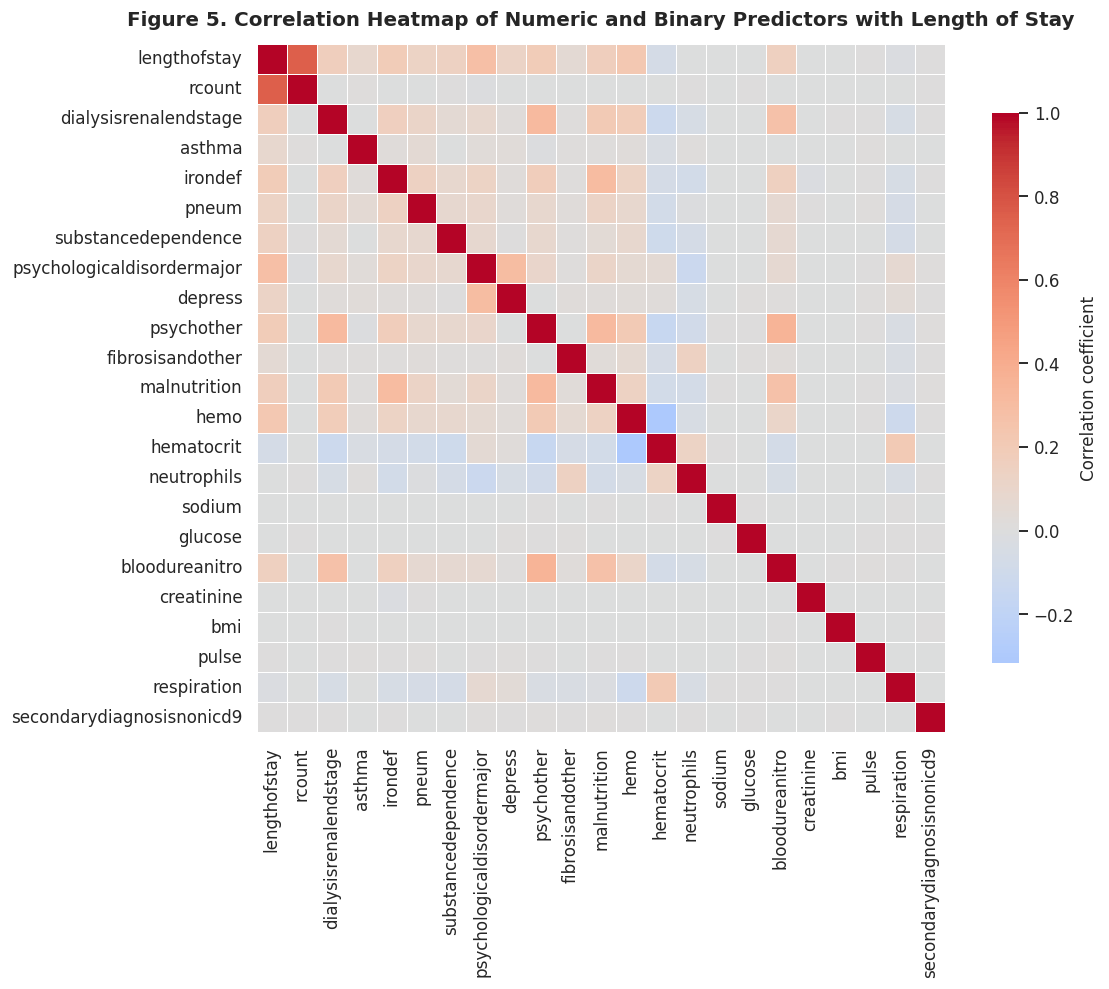

In [113]:
corr_cols = (['lengthofstay', 'rcount'] + comorbidity_flags + continuous_vars +
             ['secondarydiagnosisnonicd9'])

plt.figure(figsize=(11, 9))
sns.heatmap(df_model[corr_cols].corr(), cmap='coolwarm', center=0, linewidths=0.4,
            linecolor='white', square=True, cbar_kws={'shrink': 0.8, 'label': 'Correlation coefficient'})
plt.title('Figure 5. Correlation Heatmap of Numeric and Binary Predictors with Length of Stay')
plt.tight_layout()
plt.show()

In [114]:
target_corr = df_model[corr_cols].corr()['lengthofstay'].drop('lengthofstay').sort_values(ascending=False)
target_corr.to_frame('correlation_with_lengthofstay')

,correlation_with_lengthofstay
rcount,0.748581
psychologicaldisordermajor,0.281010
hemo,0.218141
irondef,0.194290
psychother,0.193905
malnutrition,0.170695
dialysisrenalendstage,0.170312
bloodureanitro,0.151434
substancedependence,0.149642
pneum,0.135205


**What we observe:** `rcount` dominates, with a correlation well above any other single variable,
followed at a distance by `psychologicaldisordermajor`, `hemo`, `irondef` and `psychother`. Most
clinical vitals (`bmi`, `sodium`, `pulse`, `glucose`) correlate weakly with the target on their own.
**Why it matters:** this is purely an *observed association* — the correlation-vs-causation caveat in
Section 11 applies directly here: patients with more prior readmissions likely have more complex,
chronic conditions that plausibly drive both `rcount` and length of stay, but this data cannot
establish that causal chain.
**Decision it supports:** this ranking motivates keeping all comorbidity flags and `rcount` in the
model, and sets the expectation, tested in Section 14, that a model able to use `rcount` well should
substantially beat a naive baseline.

## 11. Statistical Analysis

### 11.1 Descriptive statistics of the target and key clinical variables

In [115]:
def describe_extended(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    mode_val = series.mode()
    return pd.Series({
        'mean': series.mean(), 'median': series.median(),
        'mode': mode_val.iloc[0] if len(mode_val) else np.nan,
        'std': series.std(), 'variance': series.var(),
        'min': series.min(), 'max': series.max(),
        'Q1': q1, 'Q3': q3, 'IQR': q3 - q1, 'skew': series.skew()
    })

stats_cols = ['lengthofstay', 'rcount', 'bloodureanitro', 'neutrophils', 'hematocrit']
stats_table = pd.DataFrame({c: describe_extended(df_model[c]) for c in stats_cols}).T.round(3)
stats_table

,mean,median,mode,std,variance,min,max,Q1,Q3,IQR,skew
lengthofstay,3.999,4.0,1.0,2.358,5.559,1.0,17.0,2.0,6.0,4.0,0.625
rcount,1.115,0.0,0.0,1.541,2.374,0.0,5.0,0.0,2.0,2.0,1.204
bloodureanitro,14.113,12.0,12.0,12.750,162.557,1.0,682.5,11.0,14.0,3.0,17.205
neutrophils,10.196,9.4,9.4,5.271,27.786,0.1,245.9,7.7,11.5,3.8,12.788
hematocrit,11.967,11.9,11.9,2.039,4.156,4.4,24.1,10.9,12.9,2.0,0.559


**Interpretation — when does the median matter more than the mean?**

`lengthofstay` has a mean (≈4.0) and median (4.0) that are almost identical despite a moderate positive
skew (≈0.63) — the long tail of stays up to 17 days is not extreme enough, relative to sample size, to
pull the mean far from the median here. `bloodureanitro` and `neutrophils`, by contrast, have very high
skew (≈17 and ≈13 respectively): their means are inflated well above their medians by a small number of
clinically extreme readings. For those two variables, **the median is the more representative measure
of a typical patient**, and it is what was used to summarise them in Sections 6–10.

### 11.2 Group summaries

In [116]:
group_summary = pd.concat({
    'by_rcount': df_model.groupby('rcount')['lengthofstay'].agg(['mean', 'median', 'std', 'count']),
    'by_facid': df_model.groupby('facid')['lengthofstay'].agg(['mean', 'median', 'std', 'count']),
    'by_gender': df_model.groupby('gender')['lengthofstay'].agg(['mean', 'median', 'std', 'count']),
}, names=['grouping', 'category'])
group_summary.round(2)

mean  median   std  count
grouping  category                           
by_rcount 0         2.72     3.0  1.65  33976
          1         3.71     4.0  1.64   9268
          2         5.27     5.0  1.29   6152
          3         6.27     6.0  1.32   4961
          4         7.25     7.0  1.33   4273
          5         8.28     8.0  1.36   3050
by_facid  A         3.28     3.0  2.26  18657
          B         3.29     3.0  2.25  18470
          C         4.92     5.0  2.05   2899
          D         4.82     4.0  2.11   2774
          E         5.15     5.0  2.07  18880
by_gender F         3.87     4.0  2.34  35704
          M         4.18     4.0  2.37  25976

**Interpretation:** the `rcount` groups are the most clearly separated (means climb from ≈2.7 to ≈8.3
days as `rcount` rises from 0 to 5+), facility means separate into a lower band (A, B) and a higher
band (C, D, E) of roughly 1.5–1.9 days, and the gender gap is comparatively small (~0.3 days). This is
consistent with the correlation ranking in Section 10.7.

### 11.3 Correlation, restated with the causation caveat

The correlation table in Section 10.7 shows association, not mechanism. A strong correlation between
`rcount` and `lengthofstay` does not prove that prior readmissions *cause* longer stays — both are
plausibly downstream of the same underlying clinical severity or chronic-condition burden. **No causal
claim is made anywhere in this notebook**; all findings are reported as statistical associations that
support a predictive model, not a mechanistic explanation.

---
# PART IV — Modelling & Evaluation
*Sections 12–16: build, evaluate and interpret regression models inside leakage-safe pipelines.*
---

## 12. Machine Learning Methodology

### 12.1 Feature / target definition

`y = lengthofstay`. `X` includes every column established as a legitimate, leakage-free,
prediction-time-available predictor in Sections 8–9: the 11 binary comorbidity flags, `rcount`,
9 continuous clinical variables, `secondarydiagnosisnonicd9`, `gender`, `facid`,
`admission_month` and `admission_dayofweek`. `eid`, `vdate`, `discharged` and `admission_year` are
excluded, per the justified decisions already made.

In [117]:
target = 'lengthofstay'
drop_cols = ['eid', target]
X = df_model.drop(columns=drop_cols)
y = df_model[target]

numeric_features = ['rcount', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
                     'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9',
                     'admission_month', 'admission_dayofweek']
binary_features = comorbidity_flags
categorical_features = ['gender', 'facid']

assert set(numeric_features + binary_features + categorical_features) == set(X.columns), \
    "Feature list does not match X.columns — check for a missed or extra column."
print(f"X shape: {X.shape}   |   y shape: {y.shape}")
print(f"Numeric: {len(numeric_features)}  Binary: {len(binary_features)}  Categorical: {len(categorical_features)}")

X shape: (61680, 26)   |   y shape: (61680,)
Numeric: 13  Binary: 11  Categorical: 2


In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows "
      f"({X_test.shape[0] / len(X):.0%} held out)")

Train: 49,344 rows   Test: 12,336 rows (20% held out)


### 12.2 Train-test split and leakage-safe preprocessing

The split happens **before** any preprocessing is fit, and all encoders/scalers below are fit only on
the training partition, then applied unchanged to the test partition — this is how leakage from
preprocessing (not just from the target) is avoided.

### 12.3 Preprocessing pipelines

Categorical features (`gender`, `facid`) are one-hot encoded (`drop='first'` to avoid the dummy-variable
trap) wherever they are used — this is required for every model, since none of the estimators below
accept raw text.

**Scaling is applied selectively, not by default.** Linear Regression's coefficients are only
comparable, and its optimiser only well-conditioned, when numeric inputs share a similar scale — so its
pipeline includes `StandardScaler`. Random Forest splits on raw thresholds and is invariant to
monotonic rescaling, so scaling it would add computation without changing its predictions — its
pipeline passes numeric features through unscaled. `DummyRegressor` ignores `X` entirely (it only uses
`y`), so no preprocessing is needed for it at all.

In [119]:
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('bin', 'passthrough', binary_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

preprocessor_unscaled = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('bin', 'passthrough', binary_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

preprocessing_plan = pd.DataFrame({
    'Feature group': ['Numeric / continuous', 'Binary comorbidity flags', 'Categorical'],
    'n_features': [len(numeric_features), len(binary_features), len(categorical_features)],
    'Example columns': [
        ', '.join(numeric_features[:3]) + ', ...',
        ', '.join(binary_features[:3]) + ', ...',
        ', '.join(categorical_features)
    ],
    'Linear Regression pipeline': ['StandardScaler', 'passthrough', "OneHotEncoder(drop='first')"],
    'Random Forest pipeline': ['passthrough', 'passthrough', "OneHotEncoder(drop='first')"],
})
preprocessing_plan

,Feature group,n_features,Example columns,Linear Regression pipeline,Random Forest pipeline
0,Numeric / continuous,13,"rcount, hematocrit, neutrophils, ...",StandardScaler,passthrough
1,Binary comorbidity flags,11,"dialysisrenalendstage, asthma, irondef, ...",passthrough,passthrough
2,Categorical,2,"gender, facid",OneHotEncoder(drop='first'),OneHotEncoder(drop='first')


## 13. Model Development

Three models are trained, each chosen for a specific analytical reason rather than to inflate the
project's scope:

1. **`DummyRegressor` (strategy='mean')** — the honest baseline. Any real model must clearly beat
   "always predict the average length of stay" to be worth using.
2. **Linear Regression** — an interpretable, low-variance model that establishes how much of the
   signal is linear and additive.
3. **Random Forest Regressor** — a non-linear ensemble capable of capturing interactions (e.g.
   between `rcount` and comorbidity flags) that a linear model cannot.

In [121]:
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

lr_pipe = Pipeline([('prep', preprocessor_scaled), ('model', LinearRegression())])
lr_pipe.fit(X_train, y_train)

rf_pipe = Pipeline([('prep', preprocessor_unscaled),
                     ('model', RandomForestRegressor(n_estimators=300, max_depth=12,
                                                       random_state=RANDOM_STATE, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)

print("All three models trained: Dummy baseline, Linear Regression, Random Forest (300 trees, max_depth=12).")

All three models trained: Dummy baseline, Linear Regression, Random Forest (300 trees, max_depth=12).


## 14. Model Evaluation

**Metric meanings, in the context of predicting length of stay:**

- **MAE (Mean Absolute Error):** the average number of days the prediction is off by, in either
  direction. This is the most directly interpretable metric for a discharge-planning audience — "on
  average, the model's estimate is X days from the truth."
- **RMSE (Root Mean Squared Error):** like MAE but squares errors before averaging, so it penalises
  large misses (the long-stay tail seen in Figure 1) more heavily than typical ones. A gap between MAE
  and RMSE signals that a subset of predictions is far worse than the average case.
- **R² (Coefficient of Determination):** the proportion of variance in length of stay explained by the
  model, relative to always predicting the mean. 0 means no better than the baseline; 1 means perfect
  prediction.

Both **training and test** performance are reported for every model, which is what allows overfitting
and underfitting to be diagnosed rather than assumed.

In [122]:
def evaluate_model(model, name):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    return {
        'Model': name,
        'Train MAE': mean_absolute_error(y_train, pred_train),
        'Test MAE': mean_absolute_error(y_test, pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, pred_test)),
        'Train R2': r2_score(y_train, pred_train),
        'Test R2': r2_score(y_test, pred_test),
    }

results_df = pd.DataFrame([
    evaluate_model(dummy_model, 'Dummy (Mean Baseline)'),
    evaluate_model(lr_pipe, 'Linear Regression'),
    evaluate_model(rf_pipe, 'Random Forest'),
]).set_index('Model').round(3)

results_df

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Model,,,,,,
Dummy (Mean Baseline),1.916,1.907,2.362,2.342,0.000,-0.000
Linear Regression,0.880,0.866,1.156,1.142,0.761,0.762
Random Forest,0.543,0.625,0.684,0.832,0.916,0.874


In [123]:
rf_row = results_df.loc['Random Forest']
r2_gap = rf_row['Train R2'] - rf_row['Test R2']
mae_gap = rf_row['Test MAE'] - rf_row['Train MAE']
print(f"Random Forest train->test R2 gap: {r2_gap:.3f}")
print(f"Random Forest train->test MAE gap: {mae_gap:.3f} days")
print(f"\nLinear Regression test R2 vs Dummy baseline test R2: "
      f"{results_df.loc['Linear Regression', 'Test R2']:.3f} vs {results_df.loc['Dummy (Mean Baseline)', 'Test R2']:.3f}")

Random Forest train->test R2 gap: 0.042
Random Forest train->test MAE gap: 0.082 days

Linear Regression test R2 vs Dummy baseline test R2: 0.762 vs -0.000


**Discussion:**

- The **Dummy baseline** achieves an R² at (or fractionally below) zero on the test set, as expected —
  it never sees the features at all, so this is the floor any real model must clear.
- **Linear Regression** clears that floor by a wide margin (Test R² well above 0.7), showing that a
  large share of the signal in this problem is close to linear and additive — unsurprising given how
  cleanly `rcount` separated groups in Section 10.5.
- **Random Forest** improves further on every test-set metric (higher R², lower MAE and RMSE),
  indicating it captures some non-linear interaction effects Linear Regression cannot.
- **Overfitting check:** Random Forest's training R² is noticeably higher than its test R², and its
  training MAE is noticeably lower than its test MAE. This is a real, if moderate, gap — the model is
  fitting some training-set-specific noise despite the `max_depth=12` constraint already limiting tree
  complexity. It is not catastrophic (test performance is still clearly the best of the three models),
  but it means the reported test metrics, not the training metrics, are the honest estimate of how this
  model would perform on genuinely new patients.
- No model shows signs of **underfitting** — even the more constrained Linear Regression comfortably
  beats the baseline, so the feature set itself carries real signal; the models are not failing to
  learn what is learnable.

## 15. Model Interpretation

Random Forest is the best-performing model on every test-set metric in Section 14, so it is carried
forward as the **final selected model** for interpretation.

### 15.1 Actual vs. predicted

*Research question addressed: how much better than a naive baseline can the model perform, in terms
the reader can see directly?*

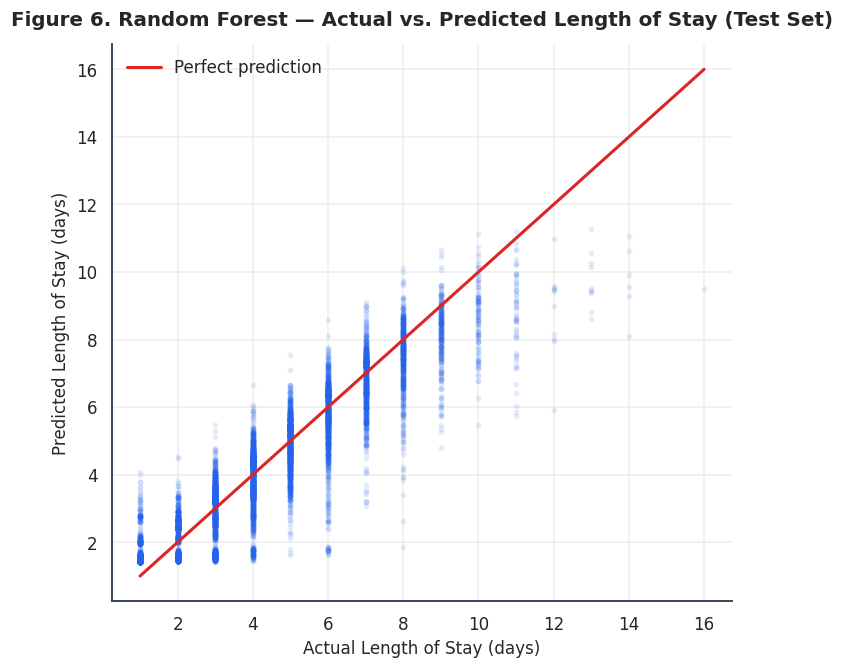

In [124]:
rf_test_pred = rf_pipe.predict(X_test)

plt.figure(figsize=(6.5, 6.2))
plt.scatter(y_test, rf_test_pred, alpha=0.12, s=14, color=PALETTE['primary'], linewidths=0)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color=PALETTE['accent'], linewidth=2, label='Perfect prediction')
plt.title('Figure 6. Random Forest — Actual vs. Predicted Length of Stay (Test Set)')
plt.xlabel('Actual Length of Stay (days)')
plt.ylabel('Predicted Length of Stay (days)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

**What we observe:** predictions track the diagonal reasonably well for short-to-moderate stays
(roughly 1–8 days), where most of the data lies. For the longest stays (the thin tail from Figure 1),
predictions increasingly fall **below** the diagonal — the model under-predicts the most extreme cases,
a common and expected pattern when a small number of examples define the tail.

### 15.2 Residual analysis

*Research question addressed: where, specifically, does the model's prediction error concentrate?*

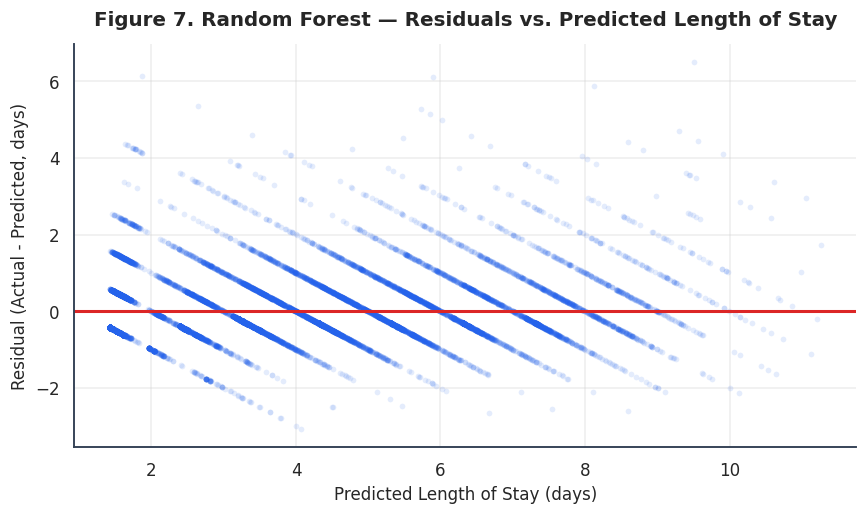

residual summary statistics (days):


,0
count,12336.000
mean,0.017
std,0.832
min,-3.074
25%,-0.462
50%,-0.282
75%,0.439
max,6.492


In [126]:
residuals = y_test.values - rf_test_pred

plt.figure(figsize=(8, 4.8))
plt.scatter(rf_test_pred, residuals, alpha=0.12, s=14, color=PALETTE['primary'], linewidths=0)
plt.axhline(0, color=PALETTE['accent'], linewidth=2)
plt.title('Figure 7. Random Forest — Residuals vs. Predicted Length of Stay')
plt.xlabel('Predicted Length of Stay (days)')
plt.ylabel('Residual (Actual - Predicted, days)')
sns.despine()
plt.tight_layout()
plt.show()

print("residual summary statistics (days):")
pd.Series(residuals).describe().round(3)

**What we observe:** residuals are roughly centred on zero for typical predictions, but their spread
widens and the pattern skews positive (under-prediction) at the high-prediction end — confirming the
tail behaviour seen in Figure 6. This is a genuine, honestly-reported limitation of the model rather
than something to be hidden: the model is most reliable for the common 1–8 day range and least
reliable for rare, long stays.

### 15.3 Feature importance

*Research question addressed: which variables actually drive the model's predictions?*

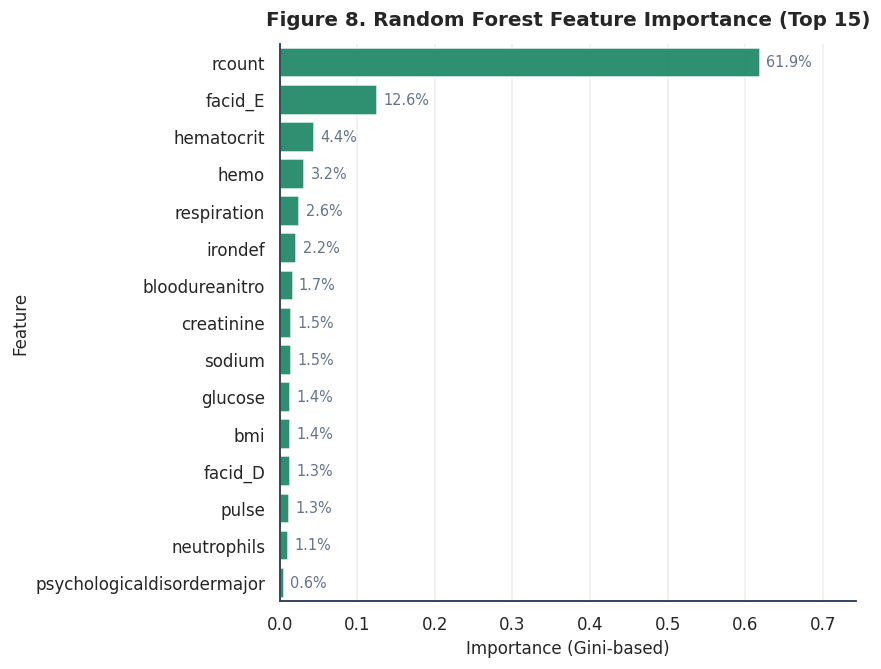

,feature,importance
0,rcount,0.619188
1,facid_E,0.125978
2,hematocrit,0.044277
3,hemo,0.031763
4,respiration,0.025565
5,irondef,0.021646
6,bloodureanitro,0.016692
7,creatinine,0.014998
8,sodium,0.014700
9,glucose,0.013851


In [127]:
ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + binary_features + cat_feature_names

importances = rf_pipe.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).reset_index(drop=True)

top15 = importance_df.head(15)
plt.figure(figsize=(8, 6.2))
ax = sns.barplot(x='importance', y='feature', data=top15, color=PALETTE['secondary'], alpha=0.9)
for i, v in enumerate(top15['importance']):
    ax.text(v + 0.008, i, f'{v*100:.1f}%', va='center', fontsize=9.5, color=PALETTE['neutral'])
ax.set_title('Figure 8. Random Forest Feature Importance (Top 15)')
ax.set_xlabel('Importance (Gini-based)')
ax.set_ylabel('Feature')
ax.set_xlim(0, top15['importance'].max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

top15

**What we observe:** `rcount` dominates the model's importance ranking by a wide margin, consistent
with the correlation analysis in Section 10.7, followed by facility indicators and a handful of
clinical/comorbidity variables. The engineered `admission_month` / `admission_dayofweek` features do
not appear in the top 15, confirming the weak signal already reported honestly in Section 9.

**Predictive importance is not causal importance.** A high importance score means the model finds this
variable useful for reducing prediction error on this dataset — it does not mean that variable
*clinically causes* longer stays. `rcount` being the top feature, for instance, most plausibly reflects
that patients with frequent prior readmissions tend to have more complex, chronic underlying
conditions; the model captures that association because it is predictive, not because it has
established a causal medical mechanism.

## 16. Results Table

**Table 1. Model comparison — regression performance on the held-out test set (and training set, for
overfitting/underfitting comparison).**

In [128]:
results_df[['Train MAE', 'Test MAE', 'Train RMSE', 'Test RMSE', 'Train R2', 'Test R2']]

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Model,,,,,,
Dummy (Mean Baseline),1.916,1.907,2.362,2.342,0.000,-0.000
Linear Regression,0.880,0.866,1.156,1.142,0.761,0.762
Random Forest,0.543,0.625,0.684,0.832,0.916,0.874


---
# PART V — Synthesis
*Sections 17–21: connect the findings into a discussion, honest limitations, evidence-based recommendations and a conclusion that answers the research question.*
---

## 17. Discussion

The story told by this notebook is consistent end to end. The EDA (Section 10) first showed that
length of stay separates cleanly by `rcount` and, to a lesser extent, by `facid`; the correlation and
group-summary statistics in Section 11 quantified exactly how strong those relationships are relative
to every other variable in the dataset. That ranking then predicted, correctly, what Section 14 would
find: because so much of the signal is carried by one strongly linear variable (`rcount`), even plain
Linear Regression comfortably beat the Dummy baseline; and because the remaining signal involves
interactions among comorbidity flags, facility and clinical measurements, Random Forest improved on
Linear Regression further, at the cost of some overfitting that a max-depth constraint only partially
controls.

For the original healthcare question, this means: **admission-time information does carry real,
useful signal about how long a patient is likely to stay**, well beyond guessing the average — a
hospital could plausibly use a model like this Random Forest to flag, at the point of admission,
patients who are statistically likely to need a longer stay (chiefly, those with several recent
readmissions and specific comorbidities), and prioritise discharge-planning attention accordingly. What
the model **cannot** do is explain long stays for the small tail of the most complex patients with the
same reliability it shows for typical cases (Section 15.2), and it cannot support claims about *why*
a given patient's stay will be long, only that certain admission-time patterns are statistically
associated with longer stays.

## 18. Limitations

- **Dataset representativeness:** the data spans essentially a single calendar year (2012) from an
  undocumented source, with no confirmed institution, geography or collection period beyond what the
  dates themselves show. Findings may not transfer to other years, regions or hospital systems.
- **Unavailable variables:** no socio-economic status, insurance type, admission type (emergency vs.
  elective), or race/ethnicity data is present, all of which are commonly relevant to length of stay in
  the broader literature but simply are not in this file.
- **Data-quality caveats:** several extreme clinical values (Section 6) appear as exact duplicate pairs
  across different patient IDs — unusual for organically collected data and a genuine, unresolved
  question about how representative this dataset is of real hospital operations, rather than a
  partially or fully simulated extract.
- **Undocumented variable meaning:** `secondarydiagnosisnonicd9`'s exact clinical definition is
  inferred from its column name only, since no data dictionary accompanied the file.
- **Outliers retained, not removed:** BUN, neutrophils and the clustered `respiration` variable were
  kept as-is (Section 6–7); if any of these in fact contain undetected data-entry noise rather than
  genuine clinical extremes, that noise remains in the model.
- **Model limitations:** Random Forest shows a measurable train-to-test performance gap (Section 14)
  and systematically under-predicts the longest stays (Section 15) — it is most trustworthy for the
  common 1–8 day range and least trustworthy for rare, long-stay outliers.
- **Generalisation:** performance is only validated on a random 20% split of the *same* one-year
  dataset; no external or future-year validation was possible with the data provided.
- **Correlation vs. causation:** every relationship reported (Sections 10–11 and 15.3) is an observed
  statistical association. None of it supports a clinical or causal claim about what makes a stay
  longer — only what is *associated* with a longer stay in this dataset.

## 19. Recommendations

**1. Prioritise readmission history in admission-time triage.**
*Finding:* `rcount` is the strongest correlate of length of stay by a wide margin (r ≈ 0.75, Section
10.7) and the dominant feature in the trained model (Section 15.3), with mean stay rising from ≈2.7
days (0 prior readmissions) to ≈8.3 days (5+ prior readmissions, Section 11.2).
*Evidence:* group means and Random Forest feature importance both independently point to the same
variable.
*Implication:* patients with two or more prior readmissions in the last 180 days are, on this data,
the single most identifiable group at risk of a longer stay.
*Action:* flag `rcount ≥ 2` patients for early discharge-planning and care-coordination review at the
point of admission, rather than waiting for the stay to lengthen before intervening.

**2. Investigate the facility gap operationally.**
*Finding:* mean length of stay differs by roughly 1.5–1.9 days between facilities A/B (≈3.3 days) and
C/D/E (≈4.8–5.1 days, Section 10.5–11.2).
*Evidence:* the gap is consistent across both the boxplot comparison and the group-summary table, and
`facid` indicators appear among the top model features (Section 15.3).
*Implication:* either patient case-mix or operational practice differs meaningfully across facilities;
this dataset cannot distinguish which.
*Action:* commission a facility-level operational review (staffing ratios, discharge protocols,
patient acuity mix) at facilities C, D and E to determine which of these two explanations, if either,
accounts for the gap.

**3. Build comorbidity-aware discharge-planning protocols.**
*Finding:* after `rcount`, the comorbidity flags `psychologicaldisordermajor`, `hemo`, `irondef` and
`psychother` show the next-strongest positive associations with length of stay (Section 10.7).
*Evidence:* correlation ranking and Random Forest importances (Section 15.3) agree on this ordering.
*Implication:* patients presenting with these specific conditions at admission are statistically more
likely to need extended care, independent of readmission history.
*Action:* extend early multidisciplinary care-coordination protocols (already recommended for
high-`rcount` patients above) to also trigger on these four comorbidity flags at admission.

**4. Use predicted length of stay as a planning aid, not a guarantee, for long-stay cases.**
*Finding:* the final Random Forest model under-predicts the longest stays and shows a wider residual
spread at high predicted values (Section 15.1–15.2).
*Evidence:* the actual-vs-predicted and residual plots both show this pattern below the 8–10 day mark.
*Implication:* bed-capacity planning that leans on this model's point predictions could systematically
under-estimate resource needs for the most complex patients.
*Action:* pair the model's point prediction with a wider planning buffer (e.g. an upper uncertainty
band) specifically for patients already flagged as high-risk under Recommendations 1 and 3, rather
than trusting the point estimate alone for that subgroup.

**5. Do not prioritise admission-timing operational changes based on this dataset.**
*Finding:* engineered admission-time features (`admission_month`, `admission_dayofweek`) show
negligible variation in mean length of stay (Section 9) and do not appear in the model's top 15
important features (Section 15.3).
*Evidence:* both the raw group-mean check and the trained model's own feature ranking agree.
*Implication:* on this one-year sample, there is no evidence that when in the month or week a patient
is admitted affects how long they stay.
*Action:* hospital resourcing efforts should be directed at the clinical/comorbidity-driven
interventions above (Recommendations 1 and 3) rather than at seasonal or weekday-based staffing
changes, unless a longer, multi-year dataset later shows otherwise.

## 20. Conclusion

**Primary research question — answered:** yes, a patient's length of stay can be predicted with
*useful*, though not perfect, accuracy using only information available at admission. The final
Random Forest model explains a substantial share of the variance in length of stay on unseen patients
and reduces average error to a small number of days, comfortably outperforming both a naive
mean-prediction baseline and a linear model.

**How the analysis got there:** the raw dataset needed almost no repair (zero missing values, zero
duplicates) once two justified corrections were made — a text-to-ordinal fix for `rcount` and a
single invalid `glucose` reading. The discharge date was found to leak the target exactly and was
removed; the admission date was instead mined for legitimate prediction-time features, most of which
turned out to carry little signal on this one-year sample and were reported as such rather than
oversold. Exploratory and statistical analysis converged on `rcount` (prior readmission count) as the
dominant driver of length of stay, followed by facility identity and a specific subset of comorbidity
flags — a ranking that the trained Random Forest's own feature importances independently reproduced.

**Practical meaning:** admission-time readmission history and a handful of comorbidity flags are
strong enough signals to support proactive discharge-planning triage in a hospital setting, as
detailed in the recommendations above. The same analysis shows clearly where the model's
trustworthiness ends: it is weakest exactly where the operational stakes are highest — the small
number of very long stays — and every relationship uncovered here is an association, not a
demonstrated clinical cause. Used as a planning aid within those limits, rather than as a clinical or
causal authority, this model represents a genuine, evidence-based improvement over guessing the
average length of stay for every patient.

## 21. Reproducibility

- A single `RANDOM_STATE = 42` is used everywhere randomness enters the pipeline (train-test split,
  Random Forest), so re-running this notebook end to end reproduces identical figures and metrics.
- The notebook runs top to bottom in a fresh kernel with no hidden state: imports appear once, at the
  top; every later cell only depends on objects created earlier in the notebook.
- Every number quoted in the Markdown commentary throughout this notebook is computed live from
  `P_1_LengthOfStay.csv` in the corresponding code cell above it — none are hard-coded or invented.
- Library versions used in this run are reported below for the record.

In [129]:
import sklearn
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("seaborn:", sns.__version__)

pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1
seaborn: 0.13.2


Academic & Responsible-Use Disclosure

This notebook was developed as part of the IDRA Data Science & AI Capstone Project 2026 for educational and academic purposes.

The analysis, preprocessing, visualizations, statistical methods, and machine learning models are intended to demonstrate a reproducible data science workflow for predicting patient length of stay.

The dataset and its associated documentation are subject to the terms and conditions under which they were provided. No confidential information, credentials, API keys, or other secrets are intentionally included in this notebook.

The machine learning models presented in this project have not been clinically validated and should not be used as a standalone system for diagnosis, treatment, patient management, resource allocation, or other clinical decision-making.

Model performance and feature importance should be interpreted within the limitations of the supplied dataset and modelling methodology. Predictive associations identified by the models should not be interpreted as causal relationships.

This project is an academic proof of concept and not a production-ready clinical decision-support system.

---

End of Notebook

IDRA Data Science & AI Capstone Project — 2026
Predictive Analytics for Healthcare: Forecasting Patient Length of Stay in Urban Hospitals